# Credit Card Customer Churn -ML

## Objectives

The aim of this notebook is to build and compare classification models to predict customers at risk of credit card churn.

The target variable is **Churn**.

## Input

Processed and cleaned customer dataset generated during the ETL stage.

## Output

- Trained classification models.
- Model performance comparison.
- Identification of key features associated with customer churn.
- Selection of the most suitable model for churn prediction.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\credit-card-customer-churn-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\credit-card-customer-churn-analysis'

---

# Section 1. Load and Review Modelling Dataset

This section loads the cleaned dataset and performs a quick review before preparing the data for machine learning.

In [4]:
import pandas as pd

df = pd.read_csv("data/processed/bank_churners_clean.csv")

df.head()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [5]:
print(f"Dataset shape: {df.shape}")
df.info()


Dataset shape: (10127, 21)
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int

---

# Section 2. Review Target Variable

The target variable `Churn` is reviewed to understand the distribution of existing and churned customers.


In [6]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
0    8500
1    1627
Name: count, dtype: int64
Churn
0    83.934038
1    16.065962
Name: proportion, dtype: float64


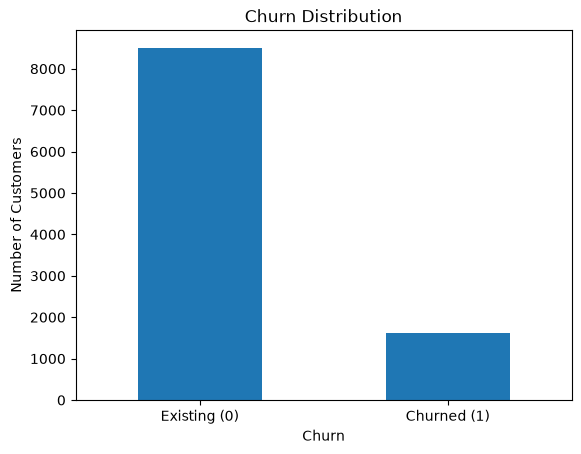

In [7]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().sort_index().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Existing (0)", "Churned (1)"], rotation=0)
plt.show()


### Interpretation

The target variable is imbalanced, with approximately **84% existing customers** and **16% churned customers**.

Therefore, model performance should not be evaluated using accuracy alone, and metrics such as **precision, recall and F1-score** should also be considered.

---

# Section 3. Define Features and Target

The dataset is separated into input features (`X`) and the target variable (`y`) for churn prediction.

In [8]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10127, 20)
y shape: (10127,)


---

# Section 4. Identify Numerical and Categorical Features

The input features are separated into numerical and categorical variables for preprocessing.

In [9]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Categorical features: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


---

# Section 5. Remove Identifier Feature

`CLIENTNUM` is a unique customer identifier and does not provide meaningful predictive information. It is removed before model training.

In [10]:
X = X.drop(columns=["CLIENTNUM"])

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

print("X shape:", X.shape)
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

X shape: (10127, 19)
Numerical features: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Categorical features: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


---

# Section 6. Train-Test Split

The dataset is split into training and testing sets. Stratification is used to preserve the churn class distribution in both datasets.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)


X_train shape: (8101, 19)
X_test shape: (2026, 19)

Training target distribution:
Churn
0    83.92791
1    16.07209
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    83.958539
1    16.041461
Name: proportion, dtype: float64


---

# Section 7. Preprocessing Pipeline

A preprocessing pipeline is created to prepare numerical and categorical features for machine learning.

- Numerical features are standardised using `StandardScaler`.
- Categorical features are encoded using `OneHotEncoder`.


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


---

# Section 8. Baseline Model - Logistic Regression

Logistic Regression is used as the baseline classification model to predict customer churn.

The preprocessing steps and the classifier are combined into a single pipeline to prevent data leakage.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


---

# Section 9. Logistic Regression Evaluation

The Logistic Regression model is evaluated using multiple classification metrics.

Accuracy, Precision, Recall, F1 Score and ROC-AUC are considered to provide a balanced assessment of model performance, particularly because the churn classes are imbalanced.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Performance")
print(f"Accuracy:  {accuracy_logistic:.3f}")
print(f"Precision: {precision_logistic:.3f}")
print(f"Recall:    {recall_logistic:.3f}")
print(f"F1 Score:  {f1_logistic:.3f}")
print(f"ROC-AUC:   {roc_auc_logistic:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))


Logistic Regression Performance
Accuracy:  0.900
Precision: 0.768
Recall:    0.538
F1 Score:  0.633
ROC-AUC:   0.917

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1701
           1       0.77      0.54      0.63       325

    accuracy                           0.90      2026
   macro avg       0.84      0.75      0.79      2026
weighted avg       0.89      0.90      0.89      2026




The confusion matrix is used to examine how well the Logistic Regression model distinguishes between existing and churned customers.

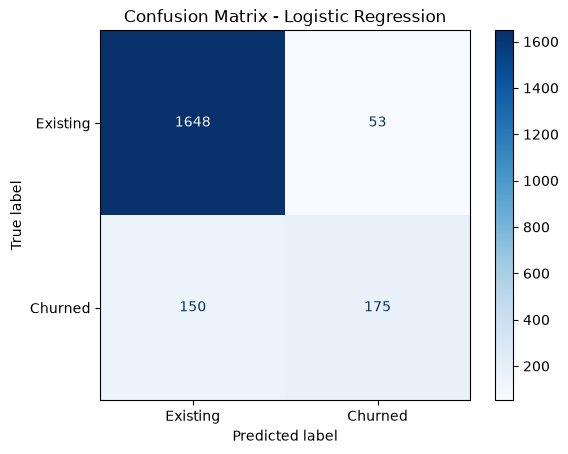

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Existing", "Churned"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


The model correctly identified 1,648 existing customers and 175 churned customers. However, 150 churned customers were incorrectly classified as existing, indicating that the model misses a notable proportion of actual churn cases.

ROC Curve - Logistic Regression:
The ROC curve is used to evaluate the model's ability to distinguish between existing and churned customers across different classification thresholds.

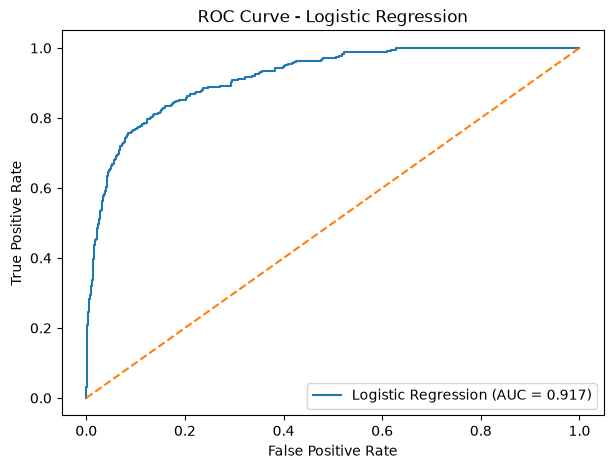

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


The Logistic Regression model achieved an ROC-AUC score of 0.917, indicating a strong ability to distinguish between existing and churned customers.

---

# Section 10.  Random Forest Model

A Random Forest classifier is trained as a second model to predict customer churn and compare its performance with the Logistic Regression baseline.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


---

## Section 11. Random Forest Evaluation

The Random Forest model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC to assess its performance in predicting customer churn.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1 Score:  {f1_rf:.3f}")
print(f"ROC-AUC:   {roc_auc_rf:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance
Accuracy:  0.952
Precision: 0.932
Recall:    0.754
F1 Score:  0.833
ROC-AUC:   0.984

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1701
           1       0.93      0.75      0.83       325

    accuracy                           0.95      2026
   macro avg       0.94      0.87      0.90      2026
weighted avg       0.95      0.95      0.95      2026



The Random Forest model achieved strong predictive performance, with an accuracy of 95.2% and an ROC-AUC score of 0.984. It also achieved a recall of 75.4% for churned customers, showing a clear improvement over the Logistic Regression baseline.

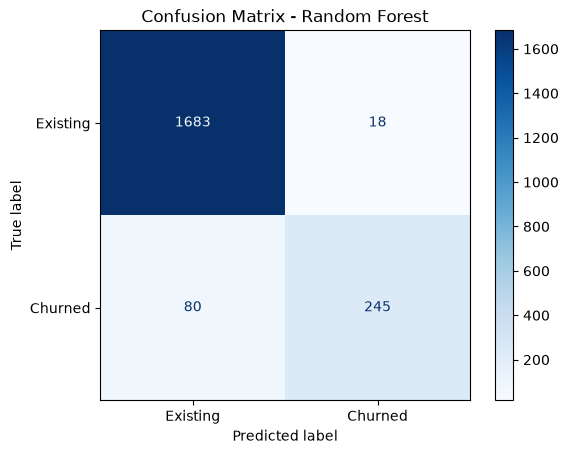

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Existing", "Churned"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()


The Random Forest model correctly identified 1,683 existing customers and 245 churned customers. Only 80 churned customers were incorrectly classified as existing, showing a clear improvement in churn detection compared with Logistic Regression.

Precision-Recall Curve - Random Forest

The Precision-Recall curve evaluates the Random Forest model's ability to identify churned customers, with particular focus on the minority churn class.

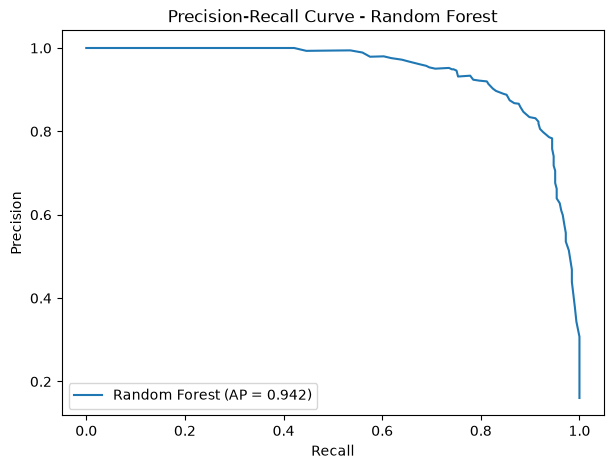

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

avg_precision = average_precision_score(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Random Forest (AP = {avg_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()

plt.show()


                      Feature  Importance
         num__Total_Trans_Amt    0.182105
          num__Total_Trans_Ct    0.155143
     num__Total_Revolving_Bal    0.109122
     num__Total_Ct_Chng_Q4_Q1    0.107489
   num__Avg_Utilization_Ratio    0.061412
    num__Total_Amt_Chng_Q4_Q1    0.060674
num__Total_Relationship_Count    0.060113
            num__Credit_Limit    0.034223
         num__Avg_Open_To_Buy    0.034023
            num__Customer_Age    0.033122


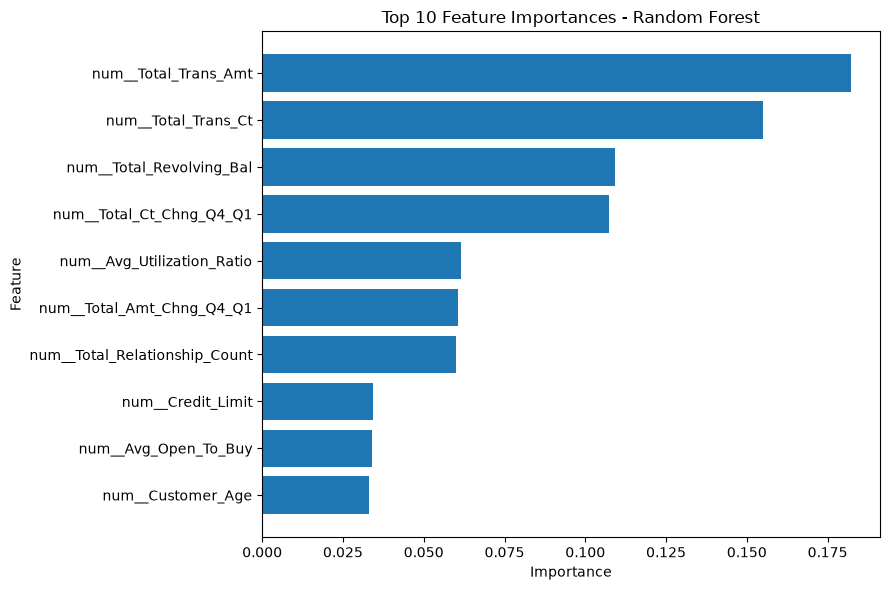

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance values
importances = random_forest_model.named_steps[
    "classifier"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

top_features = feature_importance_df.head(10)
print(top_features.to_string(index=False))

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


The Random Forest feature importance analysis shows that customer transaction and account behaviour variables are among the most influential predictors of churn. This provides insight into the factors that contribute most strongly to the model's predictions.

---

## Section 12. Model Comparison

The performance of Logistic Regression and Random Forest is compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC to identify the better model for customer churn prediction.


In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_logistic,
        precision_logistic,
        recall_logistic,
        f1_logistic,
        roc_auc_logistic
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

comparison


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.899803,0.951629
1,Precision,0.767544,0.931559
2,Recall,0.538462,0.753846
3,F1 Score,0.632911,0.833333
4,ROC-AUC,0.916720,0.984132


### Model Performance Comparison

The performance metrics of Logistic Regression and Random Forest are visualised to provide a direct comparison between the two classification models.


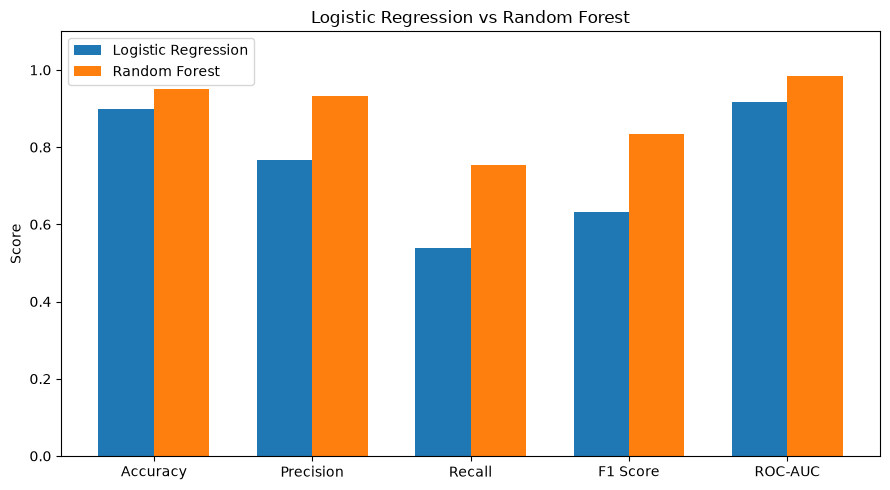

In [23]:
import numpy as np
import matplotlib.pyplot as plt

metrics = comparison["Metric"]
logistic_scores = comparison["Logistic Regression"]
rf_scores = comparison["Random Forest"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, logistic_scores, width, label="Logistic Regression")
plt.bar(x + width/2, rf_scores, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Logistic Regression vs Random Forest")
plt.legend()

plt.tight_layout()
plt.show()


Random Forest outperformed Logistic Regression across all evaluation metrics. In particular, it achieved higher Recall and F1 Score, indicating a stronger ability to identify churned customers while maintaining high prediction quality.

Therefore, Random Forest is selected as the final model for customer churn prediction.

---

## Section 13. Final Model Selection and Conclusion

Random Forest was selected as the final model for customer churn prediction because it outperformed Logistic Regression across all evaluation metrics.

The model achieved:
- **Accuracy:** 0.952
- **Precision:** 0.932
- **Recall:** 0.754
- **F1 Score:** 0.833
- **ROC-AUC:** 0.984

The results demonstrate that Random Forest provides strong overall classification performance and is particularly more effective at identifying churned customers than the Logistic Regression baseline.

The feature importance analysis also provides insight into the customer characteristics and behavioural variables that contribute most to churn predictions.

Overall, the model can support the identification of customers at higher risk of churn, enabling more targeted customer retention strategies.

---

## Section 14. Overfitting Check

The Random Forest model is evaluated on both the training and test datasets to check for potential overfitting.

In [24]:
from sklearn.metrics import accuracy_score

# Predictions
y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

# Accuracy scores
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Training Accuracy: {train_accuracy_rf:.3f}")
print(f"Test Accuracy: {test_accuracy_rf:.3f}")
print(f"Difference: {train_accuracy_rf - test_accuracy_rf:.3f}")


Training Accuracy: 1.000
Test Accuracy: 0.952
Difference: 0.048


The Random Forest achieved 100% accuracy on the training set and approximately 95.2% accuracy on the test set, resulting in a performance gap of around 4.8%.

This indicates some degree of overfitting, as the model performs perfectly on the training data. However, the relatively small reduction in test performance suggests that the model still generalises well to unseen data.